fit random forest with (almost) all variables and use it for feature selection. 

In [1]:
import pandas as pd
import numpy as np
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix #plot_confusion_matrix, 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [2]:
#read data and drop columns that would generate too many dummy variables in the one-hot encoding
dat = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
dat = dat.dropna()
dat = dat.drop(columns = "inputstate_2016") #creates too many dummy variables


#prepare data
y = dat["presvote16post_2016"]
X = dat.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

In [3]:
X_train_oh.head()

,ft_black_2016,ft_white_2016,ft_hisp_2016,ft_asian_2016,ft_muslim_2016,ft_jew_2016,ft_christ_2016,ft_fem_2016,ft_immig_2016,ft_blm_2016,...,religpew_2016_Buddhist,religpew_2016_Eastern or Greek Orthodox,religpew_2016_Hindu,religpew_2016_Jewish,religpew_2016_Mormon,religpew_2016_Muslim,religpew_2016_Nothing in particular,religpew_2016_Protestant,religpew_2016_Roman Catholic,religpew_2016_Something else
6651,75.0,76.0,58.0,75.0,50.0,81.0,51.0,100.0,41.0,50.0,...,0,0,0,0,0,0,0,1,0,0
552,91.0,99.0,75.0,100.0,50.0,90.0,100.0,4.0,63.0,4.0,...,0,0,0,0,0,0,0,0,1,0
1116,56.0,91.0,74.0,97.0,2.0,70.0,100.0,35.0,80.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1376,41.0,56.0,42.0,56.0,3.0,52.0,50.0,10.0,50.0,3.0,...,0,0,0,0,0,0,1,0,0,0
6421,6.0,99.0,80.0,99.0,0.0,98.0,97.0,8.0,26.0,1.0,...,0,0,0,0,0,0,0,1,0,0


In [4]:
X_test_oh.head()

,ft_black_2016,ft_white_2016,ft_hisp_2016,ft_asian_2016,ft_muslim_2016,ft_jew_2016,ft_christ_2016,ft_fem_2016,ft_immig_2016,ft_blm_2016,...,religpew_2016_Buddhist,religpew_2016_Eastern or Greek Orthodox,religpew_2016_Hindu,religpew_2016_Jewish,religpew_2016_Mormon,religpew_2016_Muslim,religpew_2016_Nothing in particular,religpew_2016_Protestant,religpew_2016_Roman Catholic,religpew_2016_Something else
5850,67.0,92.0,78.0,51.0,44.0,58.0,90.0,52.9849,14.0,50.0,...,0,0,0,0,0,0,0,1,0,0
2971,48.0,97.0,49.0,28.0,5.0,48.0,100.0,14.0000,13.0,3.0,...,0,0,0,0,0,0,0,1,0,0
5504,57.0,48.0,51.0,49.0,51.0,47.0,49.0,52.0000,48.0,51.0,...,0,0,0,0,0,0,0,1,0,0
918,49.0,100.0,88.0,85.0,0.0,89.0,100.0,0.0000,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1314,70.0,81.0,89.0,80.0,70.0,75.0,61.0,75.0000,80.0,60.0,...,0,0,0,0,0,0,0,0,0,0


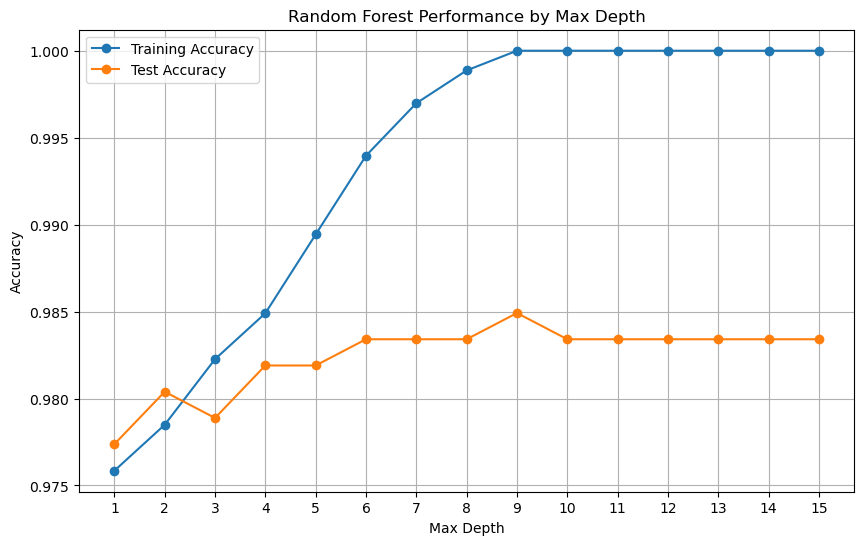

In [5]:
# Initialize lists to store results
depths = list(range(1, 16))
train_accuracies = []
test_accuracies = []

# Run Random Forest for each depth
for i in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=123,
        max_depth=i,
        #max_features = 20
    )
    rf.fit(X_train_oh, y_train)

    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['max_depth'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by Max Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

# Display the DataFrame
#print("\nResults DataFrame:")
#print(results_df)

In [6]:
#attempt with limiting max_features
#don't use
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6, max_features = 10)
rf.fit(X_train_oh, y_train)

print(f"Train accuracy depth 6: ", rf.score(X_train_oh, y_train))
print(f"Test accuracy depth 6", rf.score(X_test_oh, y_test))

Train accuracy depth 6:  0.9875471698113207
Test accuracy depth 6 0.9788838612368024


                 precision    recall  f1-score   support

   Donald Trump       0.98      0.99      0.98       313
Hillary Clinton       0.99      0.98      0.99       350

       accuracy                           0.98       663
      macro avg       0.98      0.99      0.98       663
   weighted avg       0.98      0.98      0.98       663



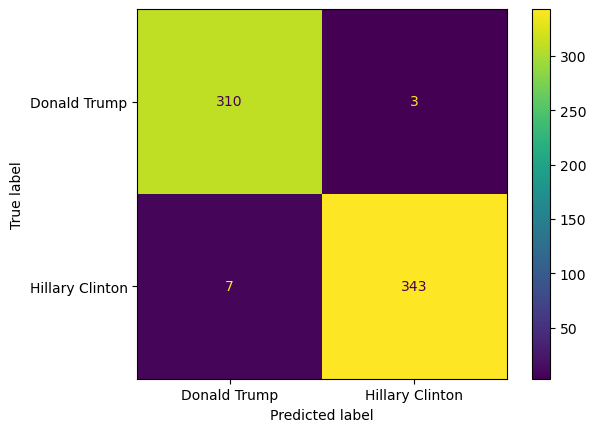

In [7]:
# run random forest with prefered depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6)
rf.fit(X_train_oh, y_train)

y_pred = rf.predict(X_test_oh)
cmat = confusion_matrix(y_test, y_pred, labels = rf.classes_)
ConfusionMatrixDisplay(cmat, display_labels = rf.classes_).plot()

#classification report
print(classification_report(y_test, y_pred))

### extract feature importances
- method 1: using mean decrease in gini impurities
- method 2: using feature permutation. I believe this is the better approach since we have high-cardinality features

#### feature importance using mean decrease in gini impurities

In [8]:
#extract feature importance and regroup by dummy variable
#e. g. sum over the rows "presvote16post_2016_Hillary Clinton" and "presvote16post_2016_Donald Trump"

#this can be used for feature selection


#create df
imp = rf.feature_importances_
imp_names = rf.feature_names_in_
imp_df = pd.DataFrame({"imp" : imp, "imp_names" : imp_names})

# Extract the base name (everything before the last underscore)
imp_df["base_name"] = imp_df["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
imp_df_grouped = imp_df.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
imp_df_grouped = imp_df_grouped.rename(columns = {"imp": "imp_grouped"})

imp_df_grouped.head(25)

,base_name,imp_grouped
16,Sanders_Trump_2016,0.097259
2,Clinton_Cruz_2016,0.092816
3,Clinton_Rubio_2016,0.078734
52,fav_trump_2016,0.065068
46,fav_hrc_2016,0.058606
47,fav_obama_2016,0.056287
81,healthreformbill_2016,0.056107
15,Sanders_Rubio_2016,0.054352
120,obamaapp_2016,0.036509
130,policies_favor_2016,0.029800


In [9]:
#individual feature importances for comparison
imp_df.sort_values("imp", ascending = False).head(25)

,imp,imp_names,base_name
34,0.057495,Clinton_Cruz_2016_Hillary Clinton (Democratic),Clinton_Cruz_2016
61,0.053366,fav_trump_2016_Very unfavorable,fav_trump_2016
86,0.052353,fav_hrc_2016_Very unfavorable,fav_hrc_2016
36,0.052292,Sanders_Trump_2016_Bernie Sanders (Democratic),Sanders_Trump_2016
31,0.048425,Clinton_Rubio_2016_Hillary Clinton (Democratic),Clinton_Rubio_2016
38,0.044734,Sanders_Trump_2016_Donald Trump (Republican),Sanders_Trump_2016
302,0.033465,healthreformbill_2016_Repealed,healthreformbill_2016
35,0.033207,Clinton_Cruz_2016_Ted Cruz (Republican),Clinton_Cruz_2016
81,0.032244,fav_obama_2016_Very unfavorable,fav_obama_2016
32,0.029704,Clinton_Rubio_2016_Marco Rubio (Republican),Clinton_Rubio_2016


#### feature importance using permutation importance

In [12]:
#feature importance based on permutation importance
#this takes a few minutes to run

from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test_oh, y_test, random_state=42, n_jobs=-1
)

NameError: name 'feature_names' is not defined

In [28]:
#create df
imp = result.importances_mean
imp_names = rf.feature_names_in_
permutation_importances = pd.DataFrame({"imp_names" : imp_names, "imp" : imp})

# Extract the base name (everything before the last underscore)
permutation_importances["base_name"] = permutation_importances["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
permutation_importances_grouped = permutation_importances.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
permutation_importances_grouped = permutation_importances_grouped.rename(columns = {"imp": "imp_grouped"})

permutation_importances_grouped.head(25)

,base_name,imp_grouped
52,fav_trump_2016,0.004525
46,fav_hrc_2016,0.003318
16,Sanders_Trump_2016,0.003017
110,immi_naturalize_2016,0.002413
128,pid7_2016,0.001810
147,reverse_discrimination_2016,0.001508
156,track_2016,0.001508
3,Clinton_Rubio_2016,0.001508
42,envwarm_2016,0.001207
5,RIGGED_SYSTEM_1_2016,0.001207


In [29]:
permutation_importances.sort_values('imp', ascending = False).head(25)

,imp_names,imp,base_name
61,fav_trump_2016_Very unfavorable,0.003017,fav_trump_2016
86,fav_hrc_2016_Very unfavorable,0.002413,fav_hrc_2016
261,immi_naturalize_2016_Oppose,0.001508,immi_naturalize_2016
299,healthreformbill_2016_Don't know,0.001508,healthreformbill_2016
121,track_2016_Don't know,0.001508,track_2016
269,immi_muslim_2016_Somewhat favor,0.001508,immi_muslim_2016
603,pid7_2016_Independent,0.001508,pid7_2016
36,Sanders_Trump_2016_Bernie Sanders (Democratic),0.001508,Sanders_Trump_2016
38,Sanders_Trump_2016_Donald Trump (Republican),0.001508,Sanders_Trump_2016
461,reverse_discrimination_2016_Agree,0.001207,reverse_discrimination_2016


### refit models using only selected features

In [72]:
selectedfeatures = permutation_importances_grouped['base_name'].head(25)
selectedfeatures
#= pd.concat([selectedfeatures, pd.Series['presvote16post_2016'], index = 

52                  fav_trump_2016
46                    fav_hrc_2016
16              Sanders_Trump_2016
110           immi_naturalize_2016
128                      pid7_2016
147    reverse_discrimination_2016
156                     track_2016
3               Clinton_Rubio_2016
42                    envwarm_2016
5             RIGGED_SYSTEM_1_2016
85                    imiss_b_2016
140           race_majority_2_2016
162            values_culture_2016
109               immi_muslim_2016
39                  econtrend_2016
49                  fav_rubio_2016
108        immi_makedifficult_2016
67                          ft_jew
99                    imiss_p_2016
139           race_majority_1_2016
148                   sexism1_2016
11        SOCIAL_CONFORMITY_1_2016
95                    imiss_l_2016
122              persfinretro_2016
117                 milstat_4_2016
Name: base_name, dtype: str

In [57]:
dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
featurestokeep = selectedfeatures.copy()
featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
dat_fs = dat_fs.filter(items=featurestokeep)
dat_fs = dat_fs.dropna()

#prepare data
y = dat_fs["presvote16post_2016"]
X = dat_fs.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

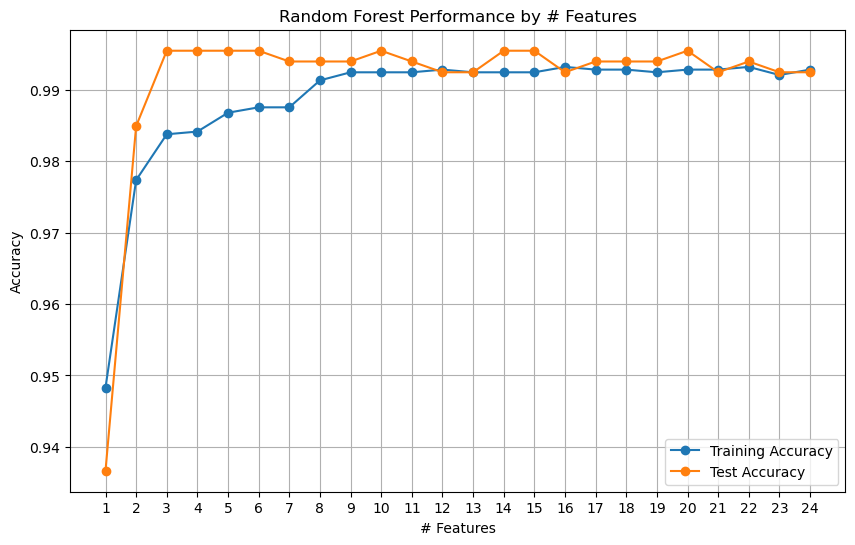

In [84]:
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

for i in featurecount:
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
    featurestokeep = selectedfeatures[0:i].copy()
    featurestokeep.loc['1'] = 'presvote16post_2016'
    dat_fs = dat_fs.filter(items=featurestokeep)
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by # Features')
plt.legend()
plt.grid(True)
plt.xticks(featurecount)
plt.show()
    